## **Machine Learning For Drug Design and Discovery**
## `Orgranized By:` Panacea Research Center
## `Topic:` Explanatory Data Analysis
## `Author:` Pritom Kundu || MD Ahad Ali
## Researcher and Trainer || Panacea Research Center, Rajshahi, Bangladeesh
## `What is CHEMBL Data Base`
The ChEMBL database is one of the most important public resources in drug discovery, medicinal chemistry, and bioinformatics. Below is a clear, consistent, and detail-focused explanation covering what it is, how it works, and why scientists use it.ChEMBL is a large, open scientific database that stores information about bioactive molecules — chemical compounds that interact with biological targets such as proteins, enzymes, or receptors.

## `In This Note Book`
We will explore a hands on go through and deep dive into the chembl data analysis RDkit descriptor calculation and learn what data are there in the data base.And How to do EDA

## Step 1 `Installing RDKit`

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 40.5 MB/s eta 0:00:00


## Step 2 `Importing the Libraries`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, Lipinski
from numpy.random import seed
from numpy.random import randn
from scipy.stats import mannwhitneyu


## Step 3 `Loading The Preprocessed Data Set Data Set`
Loading The data basically we obtained from previous class

In [ ]:
File_path = "/content/02 Preprocessed_Bioactivity_Data_CDK2.csv"
pd.read_csv(File_path)


,Unnamed: 0,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value
0,0,CHEMBL101052,COc1ccc(Nc2ccnc(Nc3ccc(OCC(O)CN(C)C)cc3)n2)cc1,inactive,36000.0
1,1,CHEMBL260416,O=C(Nc1n[nH]c2nc(-c3ccc(O)c(Br)c3)ccc12)C1CC1,active,2.0
2,2,CHEMBL84944,CC(C)C(CO)Nc1nc(NCc2cccc(O)c2)c2ncn(C(C)C)c2n1,active,30.0
3,3,CHEMBL419720,CN(C)CC(O)COc1ccc(Nc2ncc(Br)c(N(CCCC(F)(F)F)c3...,active,200.0
4,4,CHEMBL260929,O=C(Nc1n[nH]c2cc(-c3ccc[nH]3)ccc12)C1CC1,active,497.0
...,...,...,...,...,...
2774,2774,CHEMBL4208172,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)...,active,51.1
2775,2775,CHEMBL6064669,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...,active,114.0
2776,2776,CHEMBL6064669,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...,active,120.0
2777,2777,CHEMBL5748748,CC1(C)CCc2nc3c(F)cc(-c4nc(Nc5ccc6c(n5)CCN(C(=O...,active,17.6


## Step 4 `Calonizing the Smiles `
We are Basically screening Valid Smiles and removing Invalid Ones

In [ ]:
df = pd.read_csv(File_path)
df_no_smiles = df.drop(columns='canonical_smiles')

# Iterating Each SMILES and Creating EMPTY Lists
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,Unnamed: 0,molecule_chembl_id,bioactivity_class,standard_value,canonical_smiles
0,0,CHEMBL101052,inactive,36000.0,COc1ccc(Nc2ccnc(Nc3ccc(OCC(O)CN(C)C)cc3)n2)cc1
1,1,CHEMBL260416,active,2.0,O=C(Nc1n[nH]c2nc(-c3ccc(O)c(Br)c3)ccc12)C1CC1
2,2,CHEMBL84944,active,30.0,CC(C)C(CO)Nc1nc(NCc2cccc(O)c2)c2ncn(C(C)C)c2n1
3,3,CHEMBL419720,active,200.0,CN(C)CC(O)COc1ccc(Nc2ncc(Br)c(N(CCCC(F)(F)F)c3...
4,4,CHEMBL260929,active,497.0,O=C(Nc1n[nH]c2cc(-c3ccc[nH]3)ccc12)C1CC1
...,...,...,...,...,...
2774,2774,CHEMBL4208172,active,51.1,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)...
2775,2775,CHEMBL6064669,active,114.0,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...
2776,2776,CHEMBL6064669,active,120.0,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...
2777,2777,CHEMBL5748748,active,17.6,CC1(C)CCc2nc3c(F)cc(-c4nc(Nc5ccc6c(n5)CCN(C(=O...


### Step 5 `Lipinski Rule of 5 Validation and Descriptor Calculation`
According to the rule, poor absorption or permeation is more likely when a molecule violates more than one of the following criteria:
- Molecular Weight: Less than 500 daltons.
 - Hydrogen Bond Donors: No more than 5 (total number of nitrogen-hydrogen and oxygen-hydrogen bonds).
 - Hydrogen Bond Acceptors: No more than 10 (total number of nitrogen and oxygen atoms).
 - Lipophilicity (Log P): An octanol-water partition coefficient ($\text{log } P$) not greater than 5

In [ ]:
# Defines the function 'lipinski' which takes a list of SMILES and an optional verbose flag
def lipinski(smiles, verbose=False):

    # Initializes an empty list to store RDKit molecule objects
    moldata = []

    # Loops through each SMILES string in the provided input list
    for elem in smiles:
        # Converts a SMILES string into an RDKit molecule object
        mol = Chem.MolFromSmiles(elem)
        # Adds the newly created molecule object to the moldata list
        moldata.append(mol)

    # Initializes an empty list to store all calculated descriptors
    all_descriptors = []

    # Loops through each molecule object (or None) created in the first step
    for mol in moldata:
        if mol is None: # Check if the molecule object is None (invalid SMILES)
            row = [np.nan, np.nan, np.nan, np.nan] # Assign NaN for all descriptors
        else:
            # Calculates the Molecular Weight of the molecule
            desc_MolWt = Descriptors.MolWt(mol)
            # Calculates the LogP (octanol-water partition coefficient)
            desc_MolLogP = Descriptors.MolLogP(mol)
            # Calculates the number of Hydrogen Bond Donors
            desc_NumHDonors = Lipinski.NumHDonors(mol)
            # Calculates the number of Hydrogen Bond Acceptors
            desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

            # Packs the four calculated descriptors into a single list (a row)
            row = [desc_MolWt,
                    desc_MolLogP,
                    desc_NumHDonors,
                    desc_NumHAcceptors]
        all_descriptors.append(row)

    # Defines the names for the columns in the final table
    columnNames = ["MW", "LogP", "NumHDonors", "NumHAcceptors"]

    # Creates a Pandas DataFrame using the accumulated data and the column names
    descriptors = pd.DataFrame(data=all_descriptors, columns=columnNames)

    # Returns the finished DataFrame containing all calculated values
    return descriptors

In [ ]:
# Creating an Data Frame
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski

## Step 6 `Combine Two Data Frames`
1. df_lipinski
2. df_clean_smiles

In [ ]:
df_combined = pd.concat([df_clean_smiles,df_lipinski], axis=1)
df_combined

,Unnamed: 0,molecule_chembl_id,bioactivity_class,standard_value,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,0,CHEMBL101052,inactive,36000.0,COc1ccc(Nc2ccnc(Nc3ccc(OCC(O)CN(C)C)cc3)n2)cc1,409.490,3.2737,3.0,8.0
1,1,CHEMBL260416,active,2.0,O=C(Nc1n[nH]c2nc(-c3ccc(O)c(Br)c3)ccc12)C1CC1,373.210,3.4415,3.0,4.0
2,2,CHEMBL84944,active,30.0,CC(C)C(CO)Nc1nc(NCc2cccc(O)c2)c2ncn(C(C)C)c2n1,384.484,3.1537,4.0,7.0
3,3,CHEMBL419720,active,200.0,CN(C)CC(O)COc1ccc(Nc2ncc(Br)c(N(CCCC(F)(F)F)c3...,568.438,5.7646,2.0,7.0
4,4,CHEMBL260929,active,497.0,O=C(Nc1n[nH]c2cc(-c3ccc[nH]3)ccc12)C1CC1,266.304,2.9065,3.0,2.0
...,...,...,...,...,...,...,...,...,...
2774,2774,CHEMBL4208172,active,51.1,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)...,518.616,4.7289,1.0,7.0
2775,2775,CHEMBL6064669,active,114.0,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...,503.601,5.7907,1.0,6.0
2776,2776,CHEMBL6064669,active,120.0,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...,503.601,5.7907,1.0,6.0
2777,2777,CHEMBL5748748,active,17.6,CC1(C)CCc2nc3c(F)cc(-c4nc(Nc5ccc6c(n5)CCN(C(=O...,505.529,3.4684,2.0,7.0


## Step 7 `IC50 Data Normanization`
In drug discovery, data normalization is the essential process of refining raw bioactivity values, such as $IC_{50}$, into a standardized format suitable for statistical analysis and machine learning. Its primary application involves two stages: capping outliers and logarithmic transformation. By "clipping" extreme concentrations (e.g., values above $10^8$ nM), we prevent inactive compounds from skewing the dataset, followed by converting these values to a $pIC_{50}$ scale to transform exponential data into a linear, manageable range.The significance of this process lies in its ability to linearize biological relationships, ensuring that a model treats a change from 10 nM to 100 nM with the same mathematical weight as 1 µM to 10 µM. This reduces "noise," stabilizes gradients during model training, and allows for direct, intuitive comparisons where higher values consistently represent higher drug potency.

In [ ]:
# Function to limit and normalize data
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)
    return x

## Step 8 `Converting IC50 values to pIC50 values`
We convert IC50 to pIC50 primarily because IC50 values usually span several orders of magnitude (e.g., from $10^{-9}$ to $10^{-3}$ Molar), making them difficult to compare or visualize on a linear scale. By taking the negative log (calculated as $pIC_{50} = -\log_{10}(IC_{50})$), you transform these awkward, tiny decimals into small, manageable whole numbers (like 6, 7, or 8) where a higher value always means a more potent drug. This conversion is "unavoidable" in professional pharmacology and machine learning because it normalizes the data distribution, preventing high-concentration outliers from skewing your analysis and making the relationship between drug concentration and biological response much easier to map mathematically.

In [ ]:
# Defining the function to convert IC50 to pIC50
def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)

    return x

## Step 9 `Applying norm_value and pIC50 Function to the Data Frame`
We are doing this for Better EDA results

In [ ]:
df_norm = norm_value(df_combined)
df_pIC = pIC50(df_norm)
df_pIC

,Unnamed: 0,molecule_chembl_id,bioactivity_class,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,0,CHEMBL101052,inactive,COc1ccc(Nc2ccnc(Nc3ccc(OCC(O)CN(C)C)cc3)n2)cc1,409.490,3.2737,3.0,8.0,4.443697
1,1,CHEMBL260416,active,O=C(Nc1n[nH]c2nc(-c3ccc(O)c(Br)c3)ccc12)C1CC1,373.210,3.4415,3.0,4.0,8.698970
2,2,CHEMBL84944,active,CC(C)C(CO)Nc1nc(NCc2cccc(O)c2)c2ncn(C(C)C)c2n1,384.484,3.1537,4.0,7.0,7.522879
3,3,CHEMBL419720,active,CN(C)CC(O)COc1ccc(Nc2ncc(Br)c(N(CCCC(F)(F)F)c3...,568.438,5.7646,2.0,7.0,6.698970
4,4,CHEMBL260929,active,O=C(Nc1n[nH]c2cc(-c3ccc[nH]3)ccc12)C1CC1,266.304,2.9065,3.0,2.0,6.303644
...,...,...,...,...,...,...,...,...,...
2774,2774,CHEMBL4208172,active,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)...,518.616,4.7289,1.0,7.0,7.291579
2775,2775,CHEMBL6064669,active,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...,503.601,5.7907,1.0,6.0,6.943095
2776,2776,CHEMBL6064669,active,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...,503.601,5.7907,1.0,6.0,6.920819
2777,2777,CHEMBL5748748,active,CC1(C)CCc2nc3c(F)cc(-c4nc(Nc5ccc6c(n5)CCN(C(=O...,505.529,3.4684,2.0,7.0,7.754487


## Step 10 `Removing the 'intermediate' bioactivity class`
Dropping the intermediate class is a strategic data preprocessing step used to enhance the signal-to-noise ratio by removing ambiguous bioactivity data that sits between clear "hits" and "failures." In machine learning, including these "weakly active" compounds creates overlapping features that blur the decision boundary, making it difficult for an algorithm to distinguish which specific chemical structures drive potency. By filtering out the middle ground and focusing on a binary classification of strictly Active versus Inactive compounds, you reduce noise, stabilize model gradients, and ensure the resulting predictive model is much more robust for identifying high-confidence drug candidates.

In [ ]:
df_final = df_pIC[df_pIC['bioactivity_class'] != 'intermediate']
df_final

,Unnamed: 0,molecule_chembl_id,bioactivity_class,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,0,CHEMBL101052,inactive,COc1ccc(Nc2ccnc(Nc3ccc(OCC(O)CN(C)C)cc3)n2)cc1,409.490,3.2737,3.0,8.0,4.443697
1,1,CHEMBL260416,active,O=C(Nc1n[nH]c2nc(-c3ccc(O)c(Br)c3)ccc12)C1CC1,373.210,3.4415,3.0,4.0,8.698970
2,2,CHEMBL84944,active,CC(C)C(CO)Nc1nc(NCc2cccc(O)c2)c2ncn(C(C)C)c2n1,384.484,3.1537,4.0,7.0,7.522879
3,3,CHEMBL419720,active,CN(C)CC(O)COc1ccc(Nc2ncc(Br)c(N(CCCC(F)(F)F)c3...,568.438,5.7646,2.0,7.0,6.698970
4,4,CHEMBL260929,active,O=C(Nc1n[nH]c2cc(-c3ccc[nH]3)ccc12)C1CC1,266.304,2.9065,3.0,2.0,6.303644
...,...,...,...,...,...,...,...,...,...
2774,2774,CHEMBL4208172,active,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)...,518.616,4.7289,1.0,7.0,7.291579
2775,2775,CHEMBL6064669,active,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...,503.601,5.7907,1.0,6.0,6.943095
2776,2776,CHEMBL6064669,active,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...,503.601,5.7907,1.0,6.0,6.920819
2777,2777,CHEMBL5748748,active,CC1(C)CCc2nc3c(F)cc(-c4nc(Nc5ccc6c(n5)CCN(C(=O...,505.529,3.4684,2.0,7.0,7.754487


In [ ]:
# Exporting the result
df_final.to_csv('03 Bioactivity_preprocessed_EDA_data.csv', index=False)

## Step 11 `Explanatory Data Analysis`
## We Will do
- Frequency plot of the 2 bioactivity classes
- Scatter plot of MW versus LogP
- Box Plot pIC50 vs Bioactive Class
- MW vs Bioactive Class
- LogP vs Bioactive Class
- Num H Bond Donor vs Bioactive Class
-Num H bond Acceptor vs Bioactive Class
And
- **Statistical analysis mannwhitney test of all**

In [ ]:
def mannwhitney(descriptor, verbose=False):
    from numpy.random import seed
    from scipy.stats import mannwhitneyu
    import pandas as pd

    seed(1)

    # 1. Select data and DROP NaN values immediately to prevent calculation errors
    df = df_final[[descriptor, 'bioactivity_class']].dropna(subset=[descriptor])

    # 2. Extract the two groups
    active = df[df.bioactivity_class == 'active'][descriptor]
    inactive = df[df.bioactivity_class == 'inactive'][descriptor]

    # 3. Safety Check: Ensure both groups actually have data
    if len(active) == 0 or len(inactive) == 0:
        return f"Error: One of the groups for {descriptor} is empty."

    # 4. Compare samples (using 'two-sided' for a standard check)
    stat, p = mannwhitneyu(active, inactive, alternative='two-sided')

    # 5. Interpret the p-value
    alpha = 0.05
    if p > alpha:
        interpretation = 'Same distribution (fail to reject H0)'
    else:
        interpretation = 'Different distribution (reject H0)'

    # 6. Prepare the results DataFrame
    results = pd.DataFrame({
        'Descriptor': descriptor,
        'Statistics': stat,
        'p': p,
        'alpha': alpha,
        'Interpretation': interpretation
    }, index=[0])

    # 7. Save and Return
    filename = 'mannwhitneyu_' + descriptor + '.csv'
    results.to_csv(filename, index=False)

    return results

## Frequency plot of the 2 bioactivity classes

/tmp/ipykernel_291/1765726344.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='bioactivity_class', data=df_final, edgecolor='black',


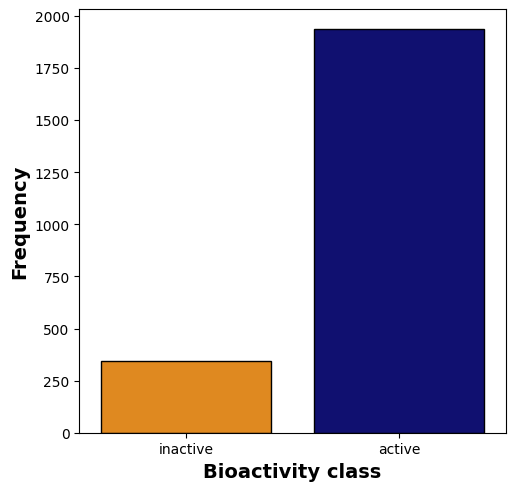

In [ ]:


# Define the figure size
plt.figure(figsize=(5.5, 5.5))

# Create the countplot with the specific colors for 'active' and 'inactive'
# 'navy' and 'darkorange' are standard CSS colors that match your request
sns.countplot(x='bioactivity_class', data=df_final, edgecolor='black',
              palette={'active': 'navy', 'inactive': 'darkorange'})

# Set the labels with bold font
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

# Save the plot as a PDF
plt.savefig('plot_bioactivity_class.pdf')

## Scatter plot of MW versus LogP

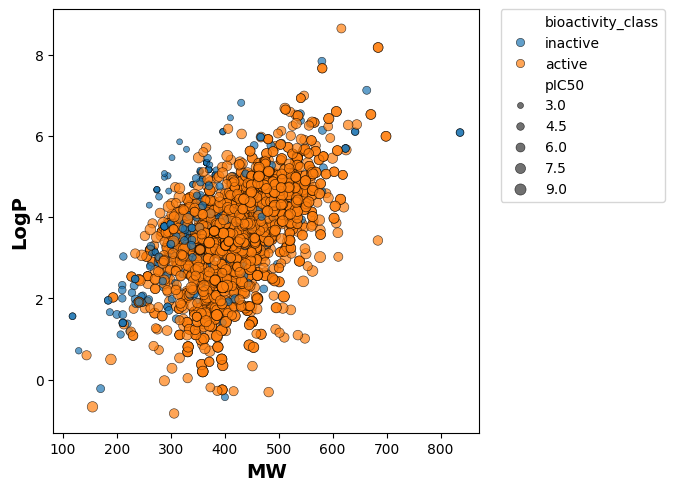

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_final, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

## Box plots pIC50 value


/tmp/ipython-input-271/3928238089.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_final,


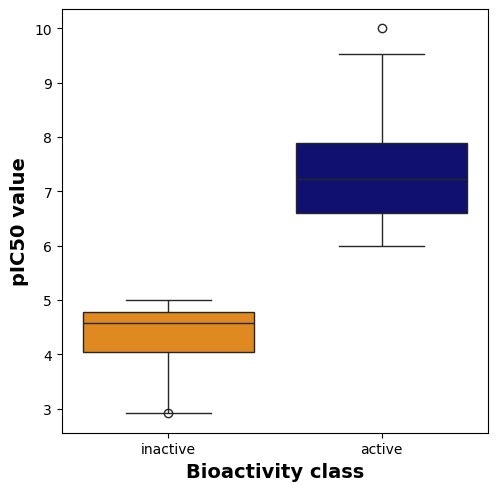

In [ ]:
plt.figure(figsize=(5.5, 5.5))

# Applying the navy and darkorange colors to the boxplot
sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_final,
            palette={'active': 'navy', 'inactive': 'darkorange'})

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

## MW vs Bioactive Class

/tmp/ipython-input-271/2882661574.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_final,


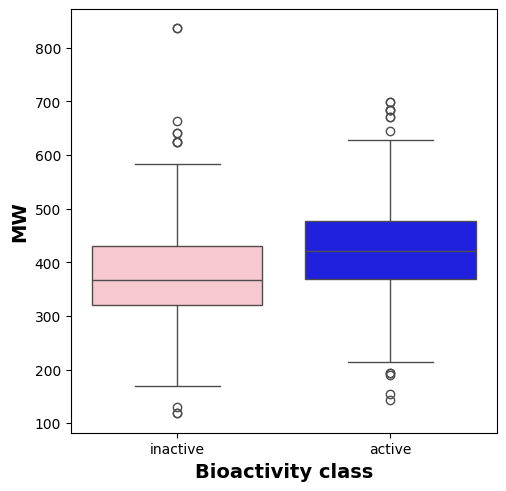

In [ ]:
# Set the figure size
plt.figure(figsize=(5.5, 5.5))

# Create the boxplot with the specified pink and blue colors
sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_final,
            palette={'active': 'blue', 'inactive': 'pink'})

# Set axis labels with bold formatting
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

# Save the resulting plot as a PDF
plt.savefig('plot_MW.pdf')


##LogP vs Bioactive Class

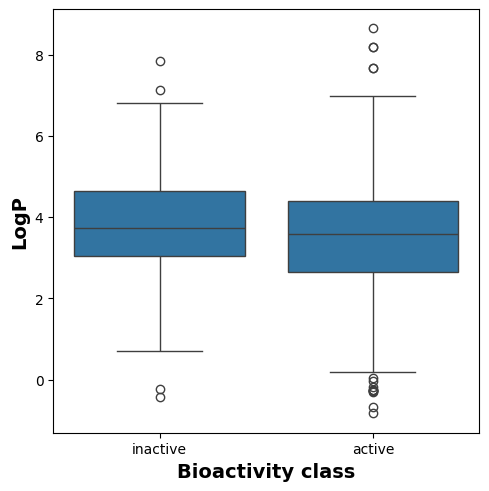

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_final)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

## NumHDonors Vs Bioactive class

/tmp/ipython-input-271/3839135835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_final,


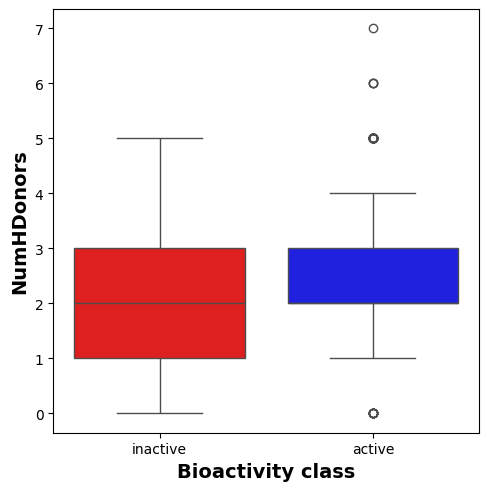

In [ ]:
# Set the figure size
plt.figure(figsize=(5.5, 5.5))

# Create the boxplot with blue for active and red for inactive
sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_final,
            palette={'active': 'blue', 'inactive': 'red'})

# Set axis labels with bold formatting
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

# Save the resulting plot as a PDF
plt.savefig('plot_NumHDonors.pdf')

## NumHAcceptors

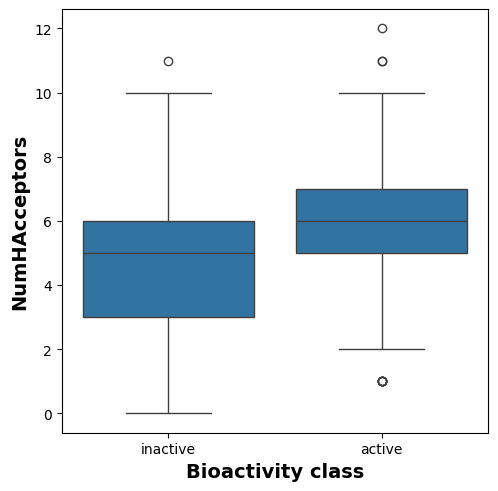

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_final)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

## Statistical Test


In [ ]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,664048.0,4.950443e-192,0.05,Different distribution (reject H0)


In [ ]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,442203.5,4.648181e-23,0.05,Different distribution (reject H0)


In [ ]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,299101.0,0.004035,0.05,Different distribution (reject H0)


In [ ]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,391809.5,1.797652e-08,0.05,Different distribution (reject H0)


In [ ]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,449763.5,3.705141e-27,0.05,Different distribution (reject H0)


In [ ]:
# Download all in zip
! zip -r results.zip . -i *.csv *.pdf

  adding: mannwhitneyu_NumHDonors.csv (deflated 10%)
  adding: plot_NumHAcceptors.pdf (deflated 37%)
  adding: mannwhitneyu_LogP.csv (deflated 8%)
  adding: 03 Bioactivity_preprocessed_EDA_data.csv (deflated 80%)
  adding: plot_bioactivity_class.pdf (deflated 39%)
  adding: plot_LogP.pdf (deflated 38%)
  adding: plot_MW_vs_LogP.pdf (deflated 2%)
  adding: 02 preprocessed_Bioactivity_Data_CDK2.csv (deflated 82%)
  adding: mannwhitneyu_pIC50.csv (deflated 10%)
  adding: plot_MW.pdf (deflated 38%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 10%)
  adding: plot_NumHDonors.pdf (deflated 37%)
  adding: plot_ic50.pdf (deflated 35%)
  adding: mannwhitneyu_MW.csv (deflated 8%)
